<a href="https://colab.research.google.com/github/praveenkumarrlgmp-source/meachin-learing-project/blob/main/Linear%20Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First 5 rows:
   number_courses  time_study   Marks
0               3       4.508  19.202
1               4       0.096   7.734
2               4       3.133  13.811
3               6       7.909  53.018
4               8       7.811  55.299

Dataset Shape:
(100, 3)

Column Names:
Index(['number_courses', 'time_study', 'Marks'], dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   number_courses  100 non-null    int64  
 1   time_study      100 non-null    float64
 2   Marks           100 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 2.5 KB
None

Statistical Summary:
       number_courses  time_study       Marks
count      100.000000  100.000000  100.000000
mean         5.290000    4.077140   24.417690
std          1.799523    2.372914   14.326199
min          3.000000    0.096000    5.609

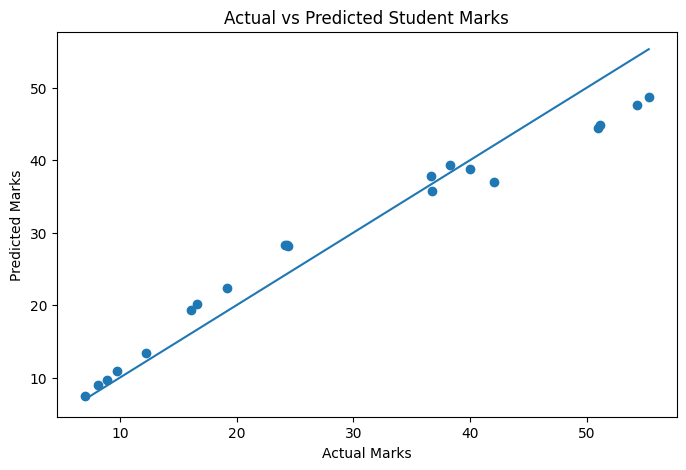

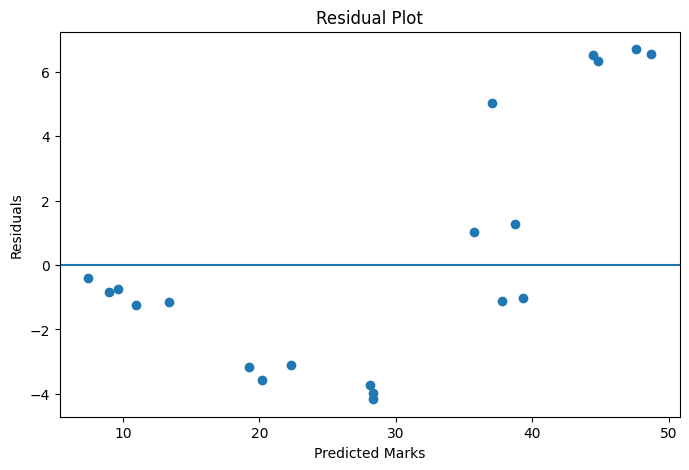


Predicted marks for new student:
26.009125628904016


In [1]:
# ============================================
# LINEAR REGRESSION - STUDENT MARKS DATASET
# ============================================

# 1. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# 2. Load the dataset
# Make sure Student_Marks.csv is in the same folder
df = pd.read_csv("Student_Marks.csv")


# 3. Display the dataset
print("First 5 rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())


# 4. Check missing values
print("\nMissing Values:")
print(df.isnull().sum())


# 5. Check duplicate values
print("\nDuplicate Rows:")
print(df.duplicated().sum())


# 6. Display correlation
print("\nCorrelation Matrix:")
print(df.corr(numeric_only=True))


# ============================================
# 7. Define X and Y
# ============================================

# Independent variables
X = df.drop("Marks", axis=1)

# Dependent variable
y = df["Marks"]


# ============================================
# 8. Split data into training and testing
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining data:", X_train.shape)
print("Testing data:", X_test.shape)


# ============================================
# 9. Create Linear Regression model
# ============================================

model = LinearRegression()

# Train the model
model.fit(X_train, y_train)


# ============================================
# 10. Make predictions
# ============================================

y_pred = model.predict(X_test)

print("\nPredicted Marks:")
print(y_pred)


# ============================================
# 11. Compare actual and predicted values
# ============================================

comparison = pd.DataFrame({
    "Actual Marks": y_test.values,
    "Predicted Marks": y_pred
})

print("\nActual vs Predicted:")
print(comparison)


# ============================================
# 12. Model coefficients
# ============================================

print("\nIntercept:")
print(model.intercept_)

print("\nCoefficients:")
for column, coefficient in zip(X.columns, model.coef_):
    print(column, ":", coefficient)


# ============================================
# 13. Evaluate the model
# ============================================

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)


print("\n========== MODEL PERFORMANCE ==========")
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R2 Score:", r2)


# ============================================
# 14. Actual vs Predicted Graph
# ============================================

plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")
plt.title("Actual vs Predicted Student Marks")

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.show()


# ============================================
# 15. Residual Plot
# ============================================

residuals = y_test - y_pred

plt.figure(figsize=(8, 5))

plt.scatter(y_pred, residuals)

plt.axhline(y=0)

plt.xlabel("Predicted Marks")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()


# ============================================
# 16. Predict marks for a new student
# ============================================

# Example:
# Replace these values according to the column order
new_student = pd.DataFrame({
    "number_courses": [5],
    "time_study": [4.5]
})

predicted_marks = model.predict(new_student)

print("\nPredicted marks for new student:")
print(predicted_marks[0])